### Aim
Write Python program to implement CNN object detection. Discuss numerous performance evaluation metrics for evaluating the object-detecting algorithms' performance.

### Step 1 - Import Packages

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

d:\Softwares\anaconda3\envs\lmlenv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


### Step 2 - Load CIFAR-10 Dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

print(f'Train : {x_train.shape}   Test : {x_test.shape}')
print(f'Image shape : {x_train[0].shape}   Pixel range : [0, 255]')

Train : (50000, 32, 32, 3)   Test : (10000, 32, 32, 3)
Image shape : (32, 32, 3)   Pixel range : [0, 255]


### Step 3 - Data Understanding and Preprocessing

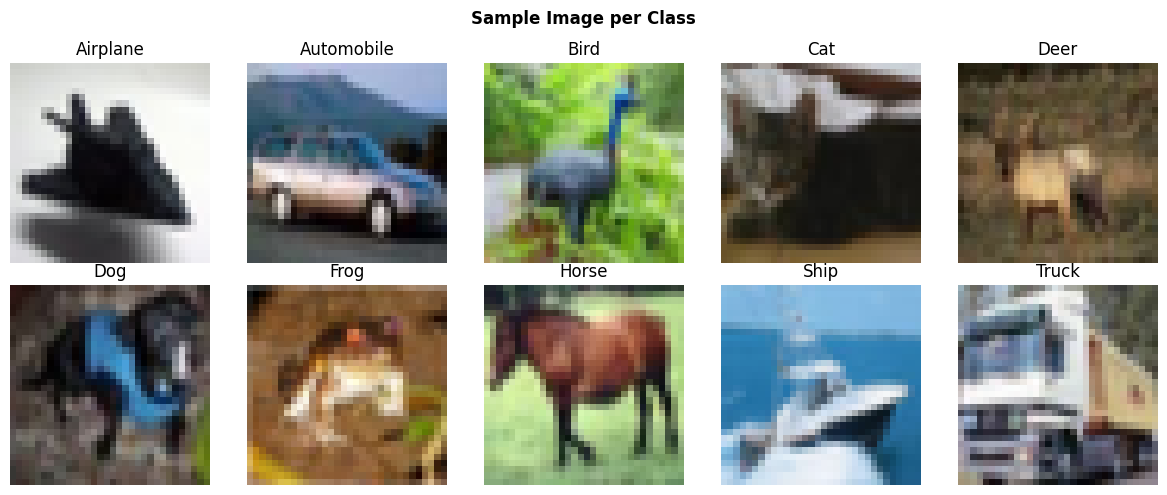

In [ ]:
# Sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    idx = np.where(y_train.flatten() == i)[0][0]
    axes[i//5, i%5].imshow(x_train[idx])
    axes[i//5, i%5].set_title(class_names[i])
    axes[i//5, i%5].axis('off')
plt.suptitle('Sample Image per Class', fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# Class distribution
_, counts = np.unique(y_train, return_counts=True)
print(f'Classes : {len(class_names)} - {counts[0]} images each (balanced)')

Classes : 10 - 5000 images each (balanced)


In [ ]:
# Normalization of Data
x_train_n = x_train.astype('float32') / 255.0
x_test_n  = x_test.astype('float32') / 255.0

### Step 4 - Build and Train CNN

In [ ]:
# Simple CNN
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

d:\Softwares\anaconda3\envs\lmlenv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training the model
history = model.fit(x_train_n, y_train, epochs=5, batch_size=64,
                    validation_split=0.1, verbose=1)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.4475 - loss: 1.5360 - val_accuracy: 0.5372 - val_loss: 1.2882
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.5812 - loss: 1.1961 - val_accuracy: 0.6022 - val_loss: 1.1291
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6255 - loss: 1.0670 - val_accuracy: 0.6284 - val_loss: 1.0618
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.6569 - loss: 0.9813 - val_accuracy: 0.6508 - val_loss: 1.0192
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.6828 - loss: 0.9106 - val_accuracy: 0.6736 - val_loss: 0.9433


### Step 5 - Evaluate Model on Test Set

In [ ]:
# Testing the model
loss, acc = model.evaluate(x_test_n, y_test, verbose=0)
print(f'Test Accuracy : {acc:.4f}')
print(f'Test Loss     : {loss:.4f}')

Test Accuracy : 0.6725
Test Loss     : 0.9609


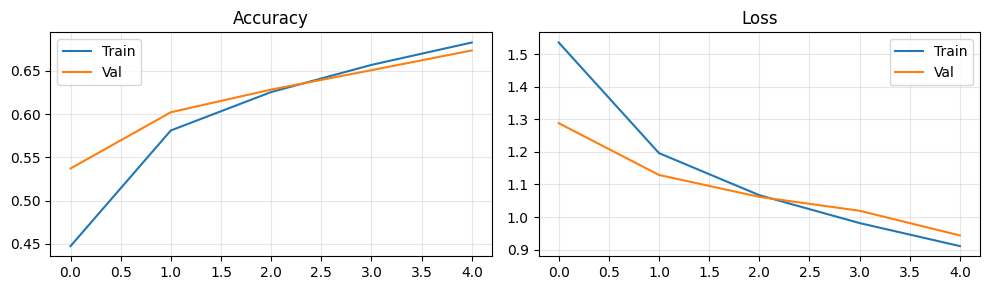

In [ ]:
# Training curves
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3))
a1.plot(history.history['accuracy'], label='Train')
a1.plot(history.history['val_accuracy'], label='Val')
a1.set_title('Accuracy'); a1.legend(); a1.grid(alpha=.3)
a2.plot(history.history['loss'], label='Train')
a2.plot(history.history['val_loss'], label='Val')
a2.set_title('Loss'); a2.legend(); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

### Step 6 - Precision, Recall, F1-Score (Per-Class)

In [ ]:
y_pred = np.argmax(model.predict(x_test_n, verbose=0), axis=1)
y_true = y_test.flatten()

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    Airplane       0.67      0.78      0.72      1000
  Automobile       0.77      0.81      0.79      1000
        Bird       0.51      0.63      0.56      1000
         Cat       0.49      0.53      0.51      1000
        Deer       0.56      0.69      0.61      1000
         Dog       0.66      0.49      0.57      1000
        Frog       0.80      0.70      0.75      1000
       Horse       0.78      0.70      0.74      1000
        Ship       0.79      0.74      0.77      1000
       Truck       0.86      0.65      0.74      1000

    accuracy                           0.67     10000
   macro avg       0.69      0.67      0.68     10000
weighted avg       0.69      0.67      0.68     10000



### Step 7 - Confusion Matrix

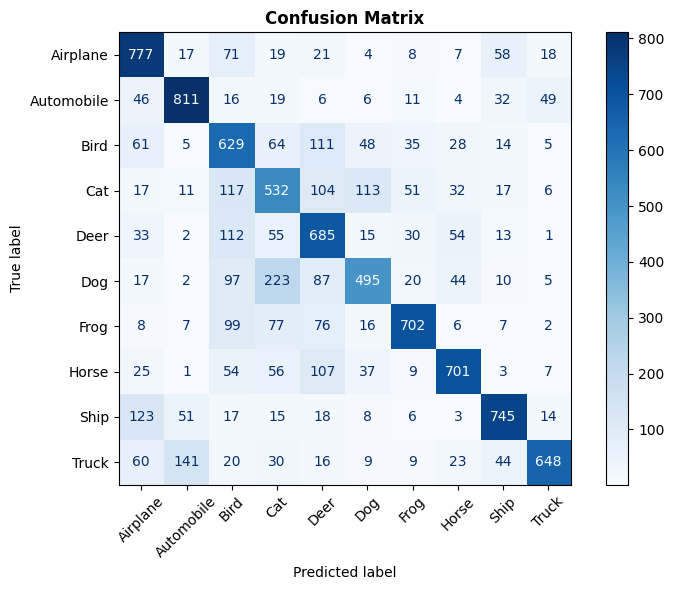

In [ ]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title('Confusion Matrix', fontweight='bold')
plt.tight_layout(); plt.show()

### Step 8 - Display Predictions on Sample Images

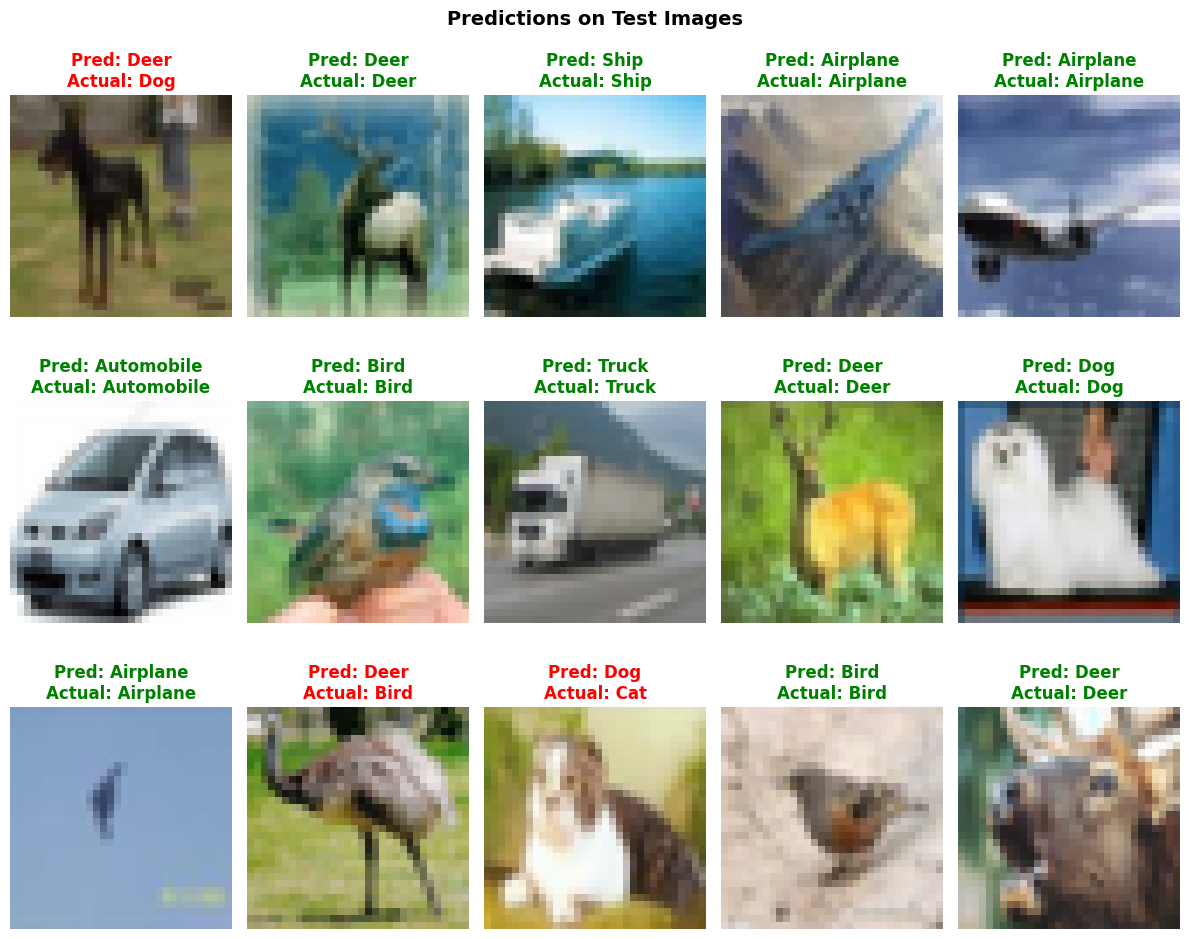

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(12, 10))
for i in range(15):
    idx = np.random.randint(0, len(x_test_n))
    ax = axes[i//5, i%5]
    ax.imshow(x_test_n[idx])
    predicted_class = class_names[y_pred[idx]]
    actual_class = class_names[y_true[idx]]
    color = 'green' if y_pred[idx] == y_true[idx] else 'red'
    ax.set_title(f'Pred: {predicted_class}\nActual: {actual_class}', color=color, fontweight='bold')
    ax.axis('off')
plt.suptitle('Predictions on Test Images', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### Step 9 - IoU (Intersection over Union)
IoU measures how well a predicted bounding box overlaps with the ground truth.

In [ ]:
def compute_iou(b1, b2):
    """IoU between two [x1, y1, x2, y2] boxes."""
    xi1, yi1 = max(b1[0],b2[0]), max(b1[1],b2[1])
    xi2, yi2 = min(b1[2],b2[2]), min(b1[3],b2[3])
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    union = (b1[2]-b1[0])*(b1[3]-b1[1]) + (b2[2]-b2[0])*(b2[3]-b2[1]) - inter
    return inter / union if union > 0 else 0

gt_box   = [50, 50, 200, 200]
pred_box = [60, 55, 210, 195]
iou = compute_iou(gt_box, pred_box)

print(f'Ground Truth : {gt_box}')
print(f'Prediction   : {pred_box}')
print(f'IoU          : {iou:.4f}')

Ground Truth : [50, 50, 200, 200]
Prediction   : [60, 55, 210, 195]
IoU          : 0.8201


### Step 10 - Inference Latency / FPS

In [ ]:
single = x_test_n[0:1]
_ = model.predict(single, verbose=0)  # warm-up

t0 = time.time()
for _ in range(20):
    model.predict(single, verbose=0)
avg = (time.time() - t0) / 20

print(f'Average latency : {avg*1000:.2f} ms')
print(f'Approximate FPS : {1/avg:.2f}')

Average latency : 115.19 ms
Approximate FPS : 8.68
